Carregar dados processados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

df = pd.read_parquet("../data/processed/escolas_limpo.parquet")
print(f"{df.shape[0]:,} escolas carregadas")

217,625 escolas carregadas


Gráfico 1: distribuição de alunos por raça no Brasil

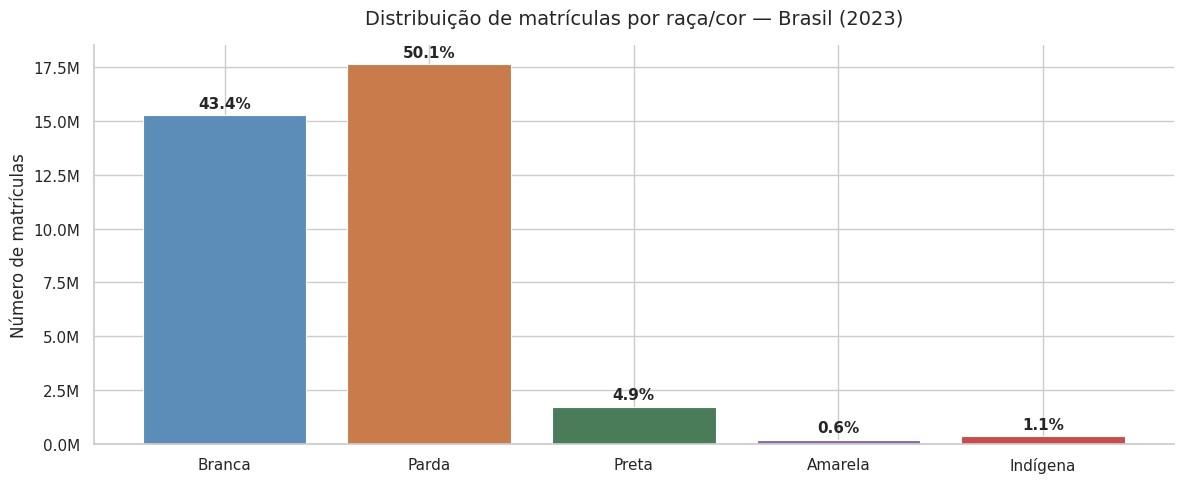

In [2]:
racas_total = {
    "Branca":   df["QT_MAT_BAS_BRANCA"].sum(),
    "Parda":    df["QT_MAT_BAS_PARDA"].sum(),
    "Preta":    df["QT_MAT_BAS_PRETA"].sum(),
    "Amarela":  df["QT_MAT_BAS_AMARELA"].sum(),
    "Indígena": df["QT_MAT_BAS_INDIGENA"].sum(),
}

total = sum(racas_total.values())
cores = ["#5B8DB8", "#C97B4B", "#4A7C59", "#8B6B9E", "#C94B4B"]

fig, ax = plt.subplots()
bars = ax.bar(racas_total.keys(), racas_total.values(), color=cores, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, racas_total.values()):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200000,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Distribuição de matrículas por raça/cor — Brasil (2023)", fontsize=14, pad=15)
ax.set_ylabel("Número de matrículas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlabel("")
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/01_distribuicao_racial.png", dpi=150)
plt.show()

Gráfico 2: acesso a internet por raça predominante da escola

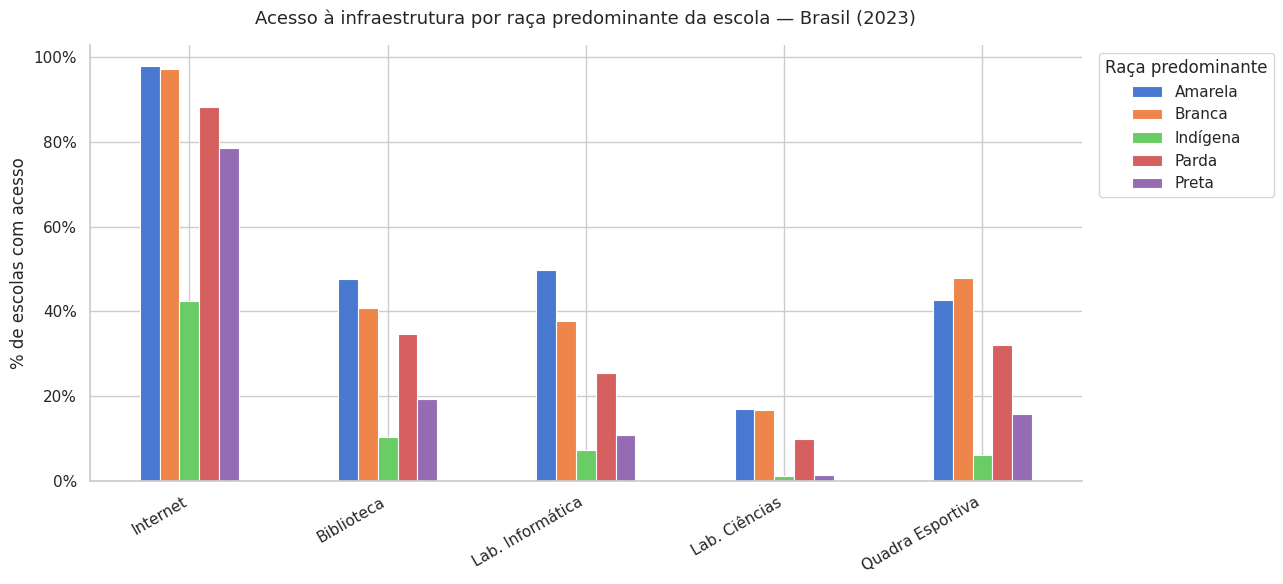

In [3]:
infra_cols = ["IN_INTERNET", "IN_BIBLIOTECA", "IN_LABORATORIO_INFORMATICA",
              "IN_LABORATORIO_CIENCIAS", "IN_QUADRA_ESPORTES"]

infra_labels = {
    "IN_INTERNET": "Internet",
    "IN_BIBLIOTECA": "Biblioteca",
    "IN_LABORATORIO_INFORMATICA": "Lab. Informática",
    "IN_LABORATORIO_CIENCIAS": "Lab. Ciências",
    "IN_QUADRA_ESPORTES": "Quadra Esportiva"
}

for col in infra_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

infra_por_raca = (
    df.groupby("RACA_PREDOMINANTE")[infra_cols]
    .mean() * 100
).rename(columns=infra_labels)

fig, ax = plt.subplots(figsize=(13, 6))
infra_por_raca.T.plot(kind="bar", ax=ax, edgecolor="white", linewidth=0.8)

ax.set_title("Acesso à infraestrutura por raça predominante da escola — Brasil (2023)",
             fontsize=13, pad=15)
ax.set_ylabel("% de escolas com acesso")
ax.set_xlabel("")
ax.legend(title="Raça predominante", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/02_infraestrutura_por_raca.png", dpi=150, bbox_inches="tight")
plt.show()

Grafico 3: desigualdade por região

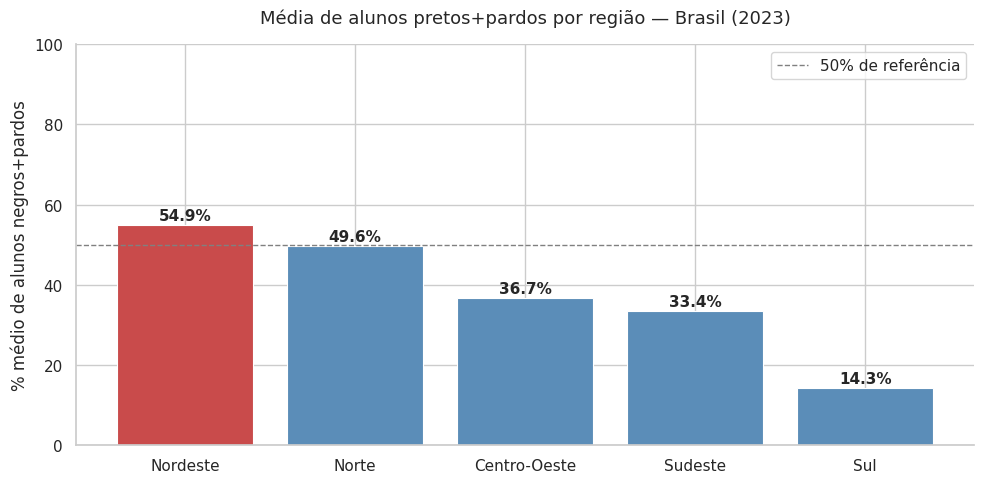

In [4]:
neg_por_regiao = (
    df.groupby("NO_REGIAO")["PERC_NEGROS"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
cores_reg = ["#C94B4B" if v > 50 else "#5B8DB8" for v in neg_por_regiao]
bars = ax.bar(neg_por_regiao.index, neg_por_regiao.values, color=cores_reg,
              edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, neg_por_regiao.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% de referência")
ax.set_title("Média de alunos pretos+pardos por região — Brasil (2023)", fontsize=13, pad=15)
ax.set_ylabel("% médio de alunos negros+pardos")
ax.set_ylim(0, 100)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/03_negros_por_regiao.png", dpi=150)
plt.show()

Gráfico 4: acesso a internet em regiões urbanas vs regiões rurais por raça

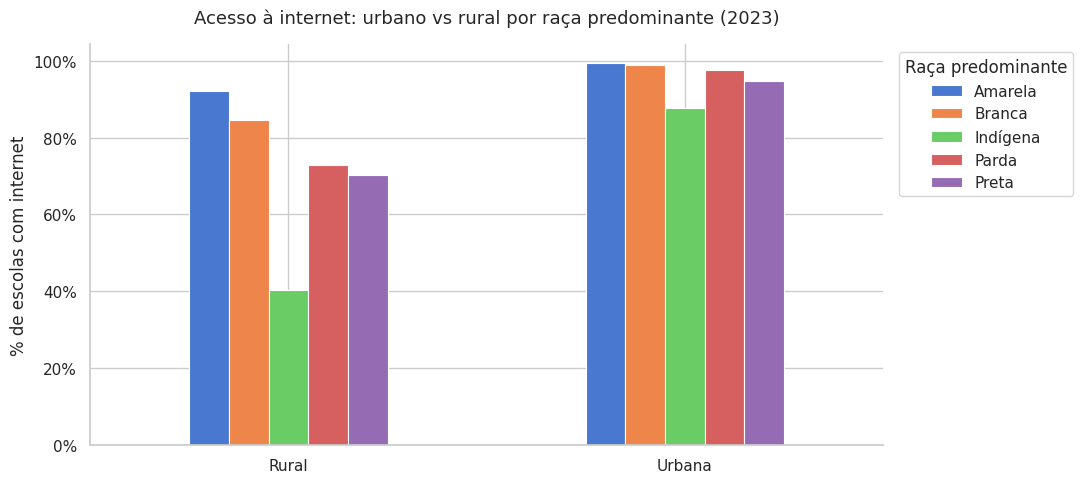

In [5]:
internet_cruzado = (
    df.groupby(["LOCALIZACAO", "RACA_PREDOMINANTE"])["IN_INTERNET"]
    .mean() * 100
).unstack("RACA_PREDOMINANTE")

fig, ax = plt.subplots(figsize=(11, 5))
internet_cruzado.plot(kind="bar", ax=ax, edgecolor="white", linewidth=0.8)

ax.set_title("Acesso à internet: urbano vs rural por raça predominante (2023)", fontsize=13, pad=15)
ax.set_ylabel("% de escolas com internet")
ax.set_xlabel("")
ax.legend(title="Raça predominante", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/04_internet_urbano_rural.png", dpi=150, bbox_inches="tight")
plt.show()